In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_absolute_error

df = pd.read_csv('../data/clean/AAPL_clean.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)
print(df.shape)
print(df.head())

(100, 6)
        date  open_price  high_price  low_price  close_price    volume
0 2025-09-29     254.560     255.000     253.01       254.43  40127687
1 2025-09-30     254.855     255.919     253.11       254.63  37704259
2 2025-10-01     255.040     258.790     254.93       255.45  48713940
3 2025-10-02     256.575     258.180     254.15       257.13  42630239
4 2025-10-03     254.665     259.240     253.95       258.02  49155614


In [3]:
df_prophet = df[['date', 'close_price']].rename(columns={
    'date': 'ds',
    'close_price': 'y'
})
print(df_prophet.head())

          ds       y
0 2025-09-29  254.43
1 2025-09-30  254.63
2 2025-10-01  255.45
3 2025-10-02  257.13
4 2025-10-03  258.02


In [4]:
train = df_prophet[:-30]  # everything except last 30 days
test = df_prophet[-30:]   # last 30 days (real values to compare against)

print("Training rows:", len(train))
print("Test rows:", len(test))

Training rows: 70
Test rows: 30


In [5]:
m = Prophet()
m.fit(train)
print("Model trained!")

10:31:09 - cmdstanpy - INFO - Chain [1] start processing
10:31:09 - cmdstanpy - INFO - Chain [1] done processing


Model trained!


In [6]:
future = m.make_future_dataframe(periods=30)
forecast = m.predict(future)

# Show the key columns
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(10))

           ds        yhat  yhat_lower  yhat_upper
90 2026-01-28  257.317319  250.137566  265.119678
91 2026-01-29  256.038336  248.454516  264.408043
92 2026-01-30  256.272347  248.122197  264.667420
93 2026-01-31 -142.310583 -150.971809 -132.752193
94 2026-02-01 -142.731217 -151.560555 -132.514044
95 2026-02-02  255.261149  245.836630  265.443983
96 2026-02-03  255.262839  245.134198  266.395872
97 2026-02-04  254.371913  244.132032  265.680728
98 2026-02-05  253.092930  242.180035  265.292746
99 2026-02-06  253.326941  242.411713  265.748251


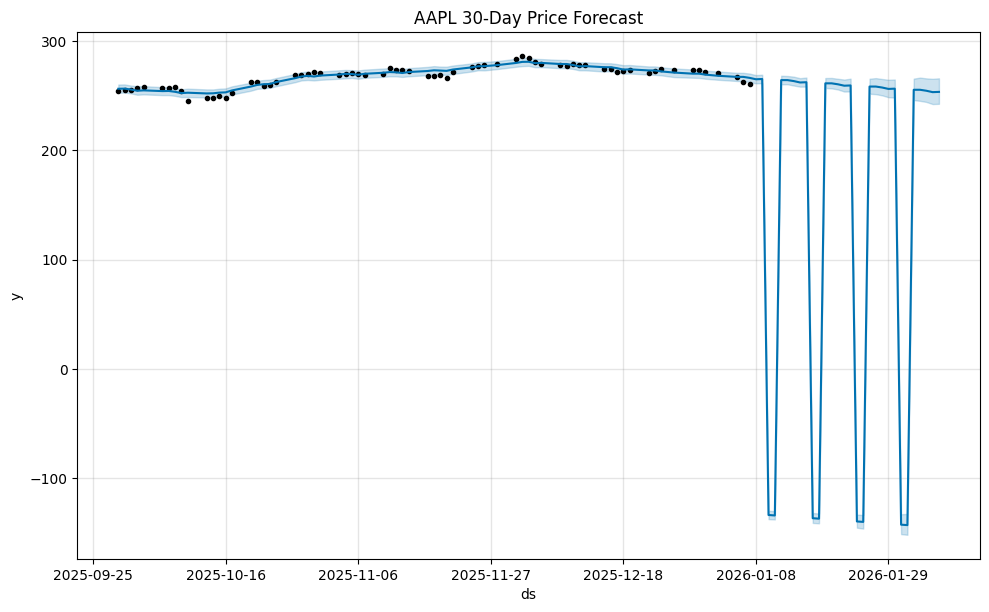

In [7]:
fig = m.plot(forecast)
plt.title('AAPL 30-Day Price Forecast')
fig.savefig('../models/forecast_plot.png')
plt.show()

In [8]:
# Get predictions for the test period only
test_forecast = forecast[forecast['ds'].isin(test['ds'])][['ds', 'yhat']]
test_actual = test[['ds', 'y']]

merged = test_actual.merge(test_forecast, on='ds')
mae = mean_absolute_error(merged['y'], merged['yhat'])

print(f"Mean Absolute Error (MAE): ${mae:.2f}")
print("This means on average the model is off by $", round(mae, 2))

Mean Absolute Error (MAE): $8.99
This means on average the model is off by $ 8.99


In [9]:
import joblib
joblib.dump(m, '../models/prophet_model.pkl')
print("Model saved!")

Model saved!


In [ ]:
## Day 3 Results
#- MAE baseline: $8.99
#- Forecast looks [reasonable / too high / too low]
#- Next step: add seasonality on Day 4 to improve it